# ✅ Manga Colorization Pix2Pix - Full Training Notebook

In [ ]:
# ✅ 安裝與下載資料集
!apt-get install git-lfs -y
!git lfs install
!git clone https://huggingface.co/datasets/MichaelP84/manga-colorization-dataset
%cd manga-colorization-dataset
!git lfs pull
%cd /content

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
Git LFS initialized.
Cloning into 'manga-colorization-dataset'...
remote: Enumerating objects: 50, done.
remote: Total 50 (delta 0), reused 0 (delta 0), pack-reused 50 (from 1)
Unpacking objects: 100% (50/50), 8.53 KiB | 970.00 KiB/s, done.
Filtering content: 100% (43/43), 19.71 GiB | 49.75 MiB/s, done.
/content/manga-colorization-dataset
/content


In [ ]:
# ✅ 提取 1,000 張圖像（256x256）
import os, io
import pandas as pd
from PIL import Image

os.makedirs("images/bw", exist_ok=True)
os.makedirs("images/color", exist_ok=True)

count = 0
for file in sorted(os.listdir("manga-colorization-dataset/data")):
    if file.endswith(".parquet"):
        df = pd.read_parquet(os.path.join("manga-colorization-dataset/data", file))
        for _, row in df.iterrows():
            try:
                Image.open(io.BytesIO(row["bw_image"]["bytes"])).resize((256, 256)).save(f"images/bw/{count:05}.png")
                Image.open(io.BytesIO(row["color_image"]["bytes"])).resize((256, 256)).save(f"images/color/{count:05}.png")
                count += 1
                if count >= 1000: break
            except: continue
        if count >= 1000: break
print(f"✅ 共儲存 {count} 對圖像")

✅ 共儲存 1000 對圖像


In [ ]:
# ✅ 建立 Dataset 與 Dataloader
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class MangaDataset(Dataset):
    def __init__(self, bw_dir, color_dir, transform):
        self.bw = sorted(os.listdir(bw_dir))
        self.color = sorted(os.listdir(color_dir))
        self.bw_dir = bw_dir
        self.color_dir = color_dir
        self.transform = transform
    def __len__(self): return len(self.bw)
    def __getitem__(self, idx):
        bw = Image.open(os.path.join(self.bw_dir, self.bw[idx])).convert("L")
        color = Image.open(os.path.join(self.color_dir, self.color[idx])).convert("RGB")
        return self.transform(bw), self.transform(color)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
ds = MangaDataset("images/bw", "images/color", transform)
dataloader = DataLoader(ds, batch_size=8, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ✅ 模型建立（U-Net + PatchGAN）
import torch.nn as nn

class UNetG(nn.Module):
    def __init__(self):
        super().__init__()
        def down(in_c, out_c): return nn.Sequential(nn.Conv2d(in_c, out_c, 4, 2, 1), nn.BatchNorm2d(out_c), nn.LeakyReLU(0.2))
        def up(in_c, out_c): return nn.Sequential(nn.ConvTranspose2d(in_c, out_c, 4, 2, 1), nn.BatchNorm2d(out_c), nn.ReLU())
        self.enc1 = down(1, 64); self.enc2 = down(64, 128); self.enc3 = down(128, 256); self.enc4 = down(256, 512)
        self.middle = down(512, 512)
        self.dec4 = up(512, 512); self.dec3 = up(1024, 256); self.dec2 = up(512, 128); self.dec1 = up(256, 64)
        self.final = nn.ConvTranspose2d(128, 3, 4, 2, 1)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(e1); e3 = self.enc3(e2); e4 = self.enc4(e3)
        m = self.middle(e4)
        d4 = self.dec4(m); d4 = torch.cat([d4, e4], 1)
        d3 = self.dec3(d4); d3 = torch.cat([d3, e3], 1)
        d2 = self.dec2(d3); d2 = torch.cat([d2, e2], 1)
        d1 = self.dec1(d2); d1 = torch.cat([d1, e1], 1)
        return torch.tanh(self.final(d1))

class PatchD(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 4, 1, 1)
        )
    def forward(self, x): return self.model(x)

In [ ]:
# ✅ 感知損失（VGG16）
from torchvision.models import vgg16, VGG16_Weights
vgg_model = vgg16(weights=VGG16_Weights.DEFAULT).features[:16].eval()
vgg = vgg_model.to(device)
for param in vgg.parameters(): param.requires_grad = False
def perceptual_loss(fake, real):
    return nn.L1Loss()(vgg(fake), vgg(real))

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:05<00:00, 93.7MB/s]


In [ ]:
from torch.cuda.amp import GradScaler, autocast
from torchvision.utils import save_image
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import matplotlib.pyplot as plt
import numpy as np
import os

G, D = UNetG().to(device), PatchD().to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=1e-4)
opt_D = torch.optim.Adam(D.parameters(), lr=1e-5)
loss_GAN = nn.BCEWithLogitsLoss()
loss_L1 = nn.L1Loss()
scaler = GradScaler()

os.makedirs("outputs", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

gen_losses, disc_losses, ssim_scores, psnr_scores = [], [], [], []
EPOCHS = 200


<ipython-input-6-f980f720ad0c>:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
for epoch in range(1, EPOCHS + 1):
    G.train(); total_G = total_D = 0
    for bw, color in dataloader:
        bw, color = bw.to(device), color.to(device)


In [ ]:
        with autocast():
            fake = G(bw)
            D_real = D(torch.cat([bw, color], 1))
            D_fake = D(torch.cat([bw, fake.detach()], 1))
            loss_D = (loss_GAN(D_real, torch.ones_like(D_real)) + loss_GAN(D_fake, torch.zeros_like(D_fake))) * 0.5

        opt_D.zero_grad()
        scaler.scale(loss_D).backward()
        scaler.step(opt_D)


<ipython-input-8-ae3b0f4d484f>:1: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


In [ ]:
        with autocast():
            D_fake = D(torch.cat([bw, fake], 1))
            if epoch <= 10:
                loss_G = 30 * loss_L1(fake, color)
            else:
                loss_G = (
                    loss_GAN(D_fake, torch.ones_like(D_fake)) +
                    30 * loss_L1(fake, color) +
                    0.1 * perceptual_loss(fake, color)
                )

        opt_G.zero_grad()
        scaler.scale(loss_G).backward()
        scaler.step(opt_G)
        scaler.update()

        total_G += loss_G.item()
        total_D += loss_D.item()


<ipython-input-9-9989ba341bb0>:1: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


In [ ]:
    gen_losses.append(total_G)
    disc_losses.append(total_D)

    G.eval()
    with torch.no_grad():
        bw_ex, color_ex = ds[0]
        bw_tensor = bw_ex.unsqueeze(0).to(device)
        pred_tensor = G(bw_tensor)[0].cpu()

        real_img = (color_ex.permute(1, 2, 0).numpy() + 1) / 2
        pred_img = (pred_tensor.permute(1, 2, 0).numpy() + 1) / 2

        ssim_val = ssim(real_img, pred_img, channel_axis=-1, data_range=1.0)
        psnr_val = psnr(real_img, pred_img, data_range=1.0)
        ssim_scores.append(ssim_val)
        psnr_scores.append(psnr_val)

    print(f"Epoch {epoch}: G Loss={total_G:.2f}, D Loss={total_D:.2f}, SSIM={ssim_val:.4f}, PSNR={psnr_val:.2f}")


Epoch 200: G Loss=21.04, D Loss=0.72, SSIM=0.0947, PSNR=9.28


In [ ]:
    if epoch % 10 == 0:
        save_image((pred_tensor + 1) / 2, f"outputs/epoch_{epoch}.png")

    if epoch % 20 == 0:
        torch.save(G.state_dict(), f"checkpoints/generator_epoch{epoch}.pth")
        torch.save(D.state_dict(), f"checkpoints/discriminator_epoch{epoch}.pth")


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


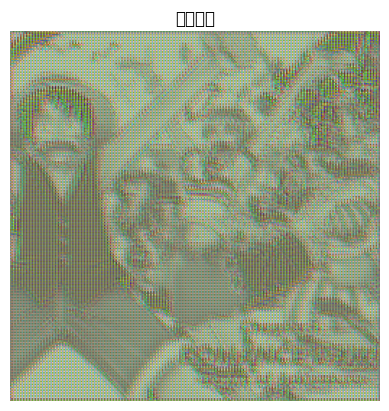

In [ ]:
# ✅ 1. 建立模型結構
G = UNetG().to(device)

# ✅ 2. 載入你想看的 .pth 模型（例如 epoch200）
G.load_state_dict(torch.load("checkpoints/generator_epoch200.pth", map_location=device))
G.eval()

# ✅ 3. 隨便選一張圖片來做預測
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

img = Image.open("images/bw/00001.png").convert("L").resize((256, 256))
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
bw_tensor = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    pred = G(bw_tensor)[0].cpu()
pred_img = (pred.permute(1, 2, 0).numpy() + 1) / 2

plt.imshow(pred_img)
plt.title("上色結果")
plt.axis("off")
plt.show()


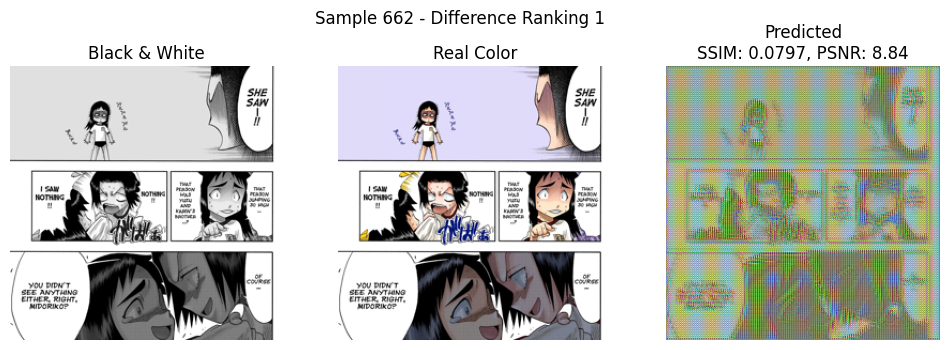

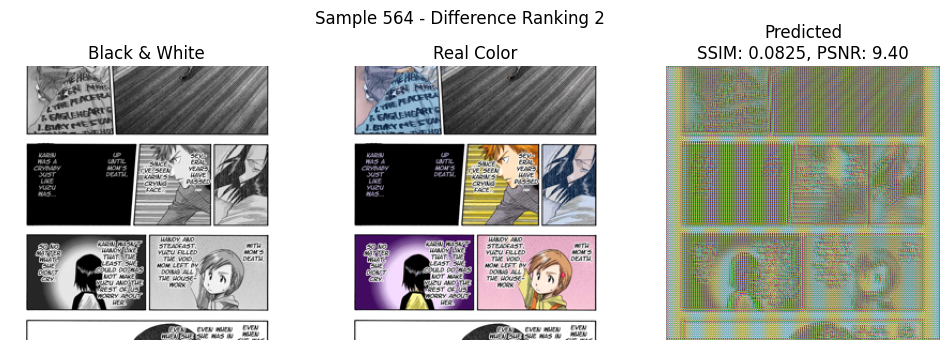

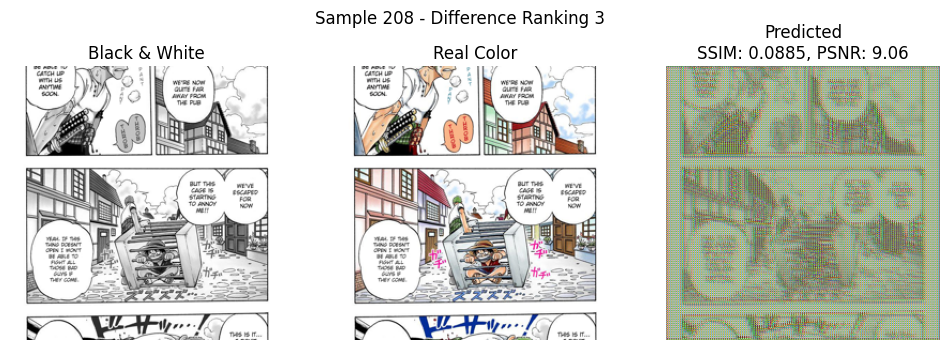

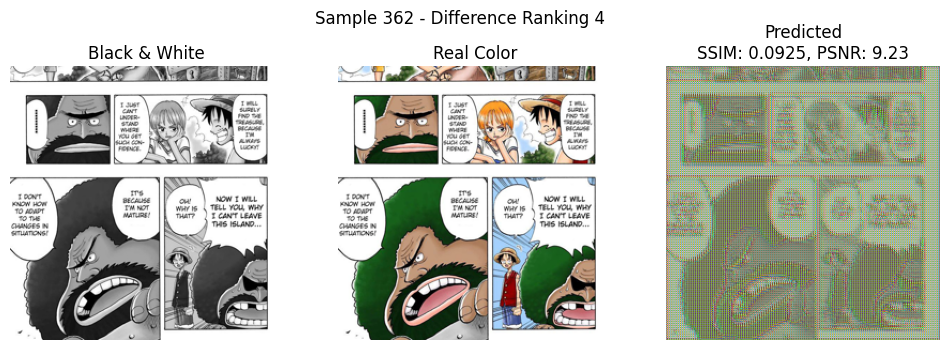

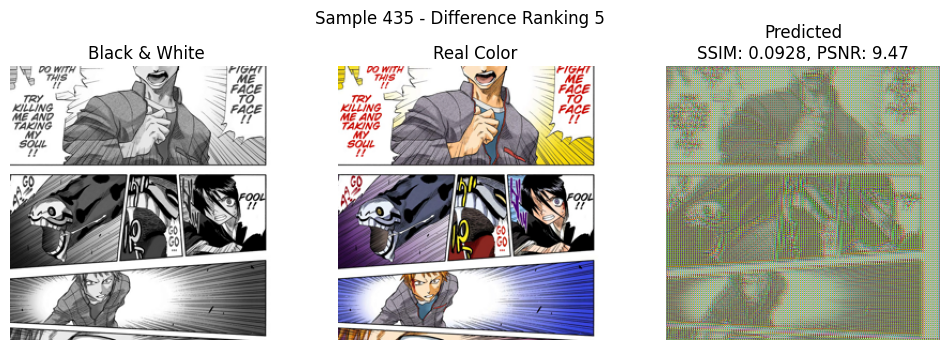

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from torchvision.utils import make_grid
import random

# 載入模型
def load_model(path):
    model = UNetG().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model

model_200 = load_model("checkpoints/generator_epoch200.pth")

# 隨機挑選10張資料
indices = random.sample(range(len(ds)), 10)

ssim_vals, psnr_vals = [], []
results = []

for idx in indices:
    bw, color = ds[idx]
    bw_tensor = bw.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model_200(bw_tensor)[0].cpu()

    # 圖像處理
    bw_np = bw[0].numpy()
    color_np = (color.permute(1, 2, 0).numpy() + 1) / 2
    pred_np = (pred.permute(1, 2, 0).numpy() + 1) / 2

    ssim_val = ssim(color_np, pred_np, channel_axis=-1, data_range=1.0)
    psnr_val = psnr(color_np, pred_np, data_range=1.0)

    ssim_vals.append(ssim_val)
    psnr_vals.append(psnr_val)

    results.append((idx, bw_np, color_np, pred_np, ssim_val, psnr_val))

# 依照 SSIM 升冪排序（找出預測誤差最明顯）
results.sort(key=lambda x: x[4])  # 排序依據 SSIM 值

# 顯示前 5 張差異最明顯的圖
for i, (idx, bw, real, pred, ssim_val, psnr_val) in enumerate(results[:5]):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(bw, cmap="gray"); axs[0].set_title("Black & White"); axs[0].axis("off")
    axs[1].imshow(real); axs[1].set_title("Real Color"); axs[1].axis("off")
    axs[2].imshow(pred); axs[2].set_title(f"Predicted\nSSIM: {ssim_val:.4f}, PSNR: {psnr_val:.2f}"); axs[2].axis("off")
    plt.suptitle(f"Sample {idx} - Difference Ranking {i+1}")
    plt.show()
